In [1]:
import numpy as np
import pandas as pd

from scformer.utils import *
from scformer.model import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
import scanpy as sc
import anndata as ad
from scipy.sparse import csr_matrix

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [2]:
adata_151673 = sc.read_10x_mtx('data/DLPFC/151673/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
metadata = pd.read_csv('data/DLPFC/151673/metadata.csv')
adata_151673.obs = metadata
adata_151673.var_names_make_unique()
adata_151673

AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'key', 'ground_truth', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 'SpatialDE_PCA_spatial', 'SpatialDE_pool_PCA_spatial', 'HVG_PCA_spatial', 'pseudobulk_PCA_spatial', 'markers_PCA_spatial', 'SpatialDE_UMAP_spatial', 'SpatialDE_pool_UMAP_spatial', 'HVG_UMAP_spatial', 'pseudobulk_UMAP_spatial', 'markers_UMAP_spatial'
    var: 'gene_ids', 'feature_types'

In [3]:
adata_151674 = sc.read_10x_mtx('data/DLPFC/151674/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
metadata = pd.read_csv('data/DLPFC/151674/metadata.tsv')
adata_151674.obs = metadata
adata_151674.var_names_make_unique()
adata_151674

AnnData object with n_obs × n_vars = 3673 × 33538
    obs: 'key', 'ground_truth', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 'SpatialDE_PCA_spatial', 'SpatialDE_pool_PCA_spatial', 'HVG_PCA_spatial', 'pseudobulk_PCA_spatial', 'markers_PCA_spatial', 'SpatialDE_UMAP_spatial', 'SpatialDE_pool_UMAP_spatial', 'HVG_UMAP_spatial', 'pseudobulk_UMAP_spatial', 'markers_UMAP_spatial'
    var: 'gene_ids', 'feature_types'

In [4]:
adata_151673.obs['batch'] = 'batch_1'
adata_151674.obs['batch'] = 'batch_2'
adata = sc.concat([adata_151673, adata_151674], join='outer', label='batch', keys=['batch1', 'batch2'])
adata

AnnData object with n_obs × n_vars = 7312 × 33538
    obs: 'key', 'ground_truth', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 'SpatialDE_PCA_spatial', 'SpatialDE_pool_PCA_spatial', 'HVG_PCA_spatial', 'pseudobulk_PCA_spatial', 'markers_PCA_spatial', 'SpatialDE_UMAP_spatial', 'SpatialDE_pool_UMAP_spatial', 'HVG_UMAP_spatial', 'pseudobulk_UMAP_spatial', 'markers_UMAP_spatial', 'batch'

In [5]:
RNA_matrix = adata.X.transpose()

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_size = 300

In [ ]:
initial_pre = initial_clustering(RNA_matrix)

cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix, cell_size=cell_size)
n_batch = len(indices)

In [ ]:
device = torch.device("cuda" if cuda.is_available() else "cpu")
node_model = NodeDimensionReduction(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                                    n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                                    num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

In [ ]:
ScFormer_model = ScFormer(gnn=gnn, h=h, labsm=0.1, n_hid=104, n_batch=n_batch, device=device, lr=0.0005, wd=0.1,
                          num_epochs=50)
ScFormer_gnn, _, _, _ = ScFormer_model.train_model(indices=indices, RNA_matrix=RNA_matrix, ini_p1=ini_p1)
ScFormer_model.save_model('scformer_model.pth')

In [ ]:
ScFormer_result = ScFormer_pred(RNA_matrix, gnn=ScFormer_gnn, indices=indices,
                                nodes_id=Node_Ids, device=device, cell_size=cell_size)
# Save numpy arrays to files
output_file = 'data/DLPFC/output/HD1_P1'
os.makedirs(output_file, exist_ok=True)
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", ScFormer_result['pred_label'])
np.save(output_file + "/cell_embedding.npy", ScFormer_result['cell_embedding'])

In [7]:
Node_Ids = np.load('data/DLPFC/output/HD1_P1/Node_Ids.npy')
Node_Ids

array([ 838,  709, 3335, ..., 1730,  109, 4743], dtype=int64)

In [8]:
cell_emb = np.load('data/DLPFC/output/HD1_P1/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm['cell_emb'] = cell_emb_sorted.values

In [9]:
pred = np.load('data/DLPFC/output/HD1_P1/pred.npy')
pred_ = pd.DataFrame(pred, index=Node_Ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')
adata

AnnData object with n_obs × n_vars = 7312 × 33538
    obs: 'key', 'ground_truth', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 'SpatialDE_PCA_spatial', 'SpatialDE_pool_PCA_spatial', 'HVG_PCA_spatial', 'pseudobulk_PCA_spatial', 'markers_PCA_spatial', 'SpatialDE_UMAP_spatial', 'SpatialDE_pool_UMAP_spatial', 'HVG_UMAP_spatial', 'pseudobulk_UMAP_spatial', 'markers_UMAP_spatial', 'batch', 'pre'
    obsm: 'cell_emb'

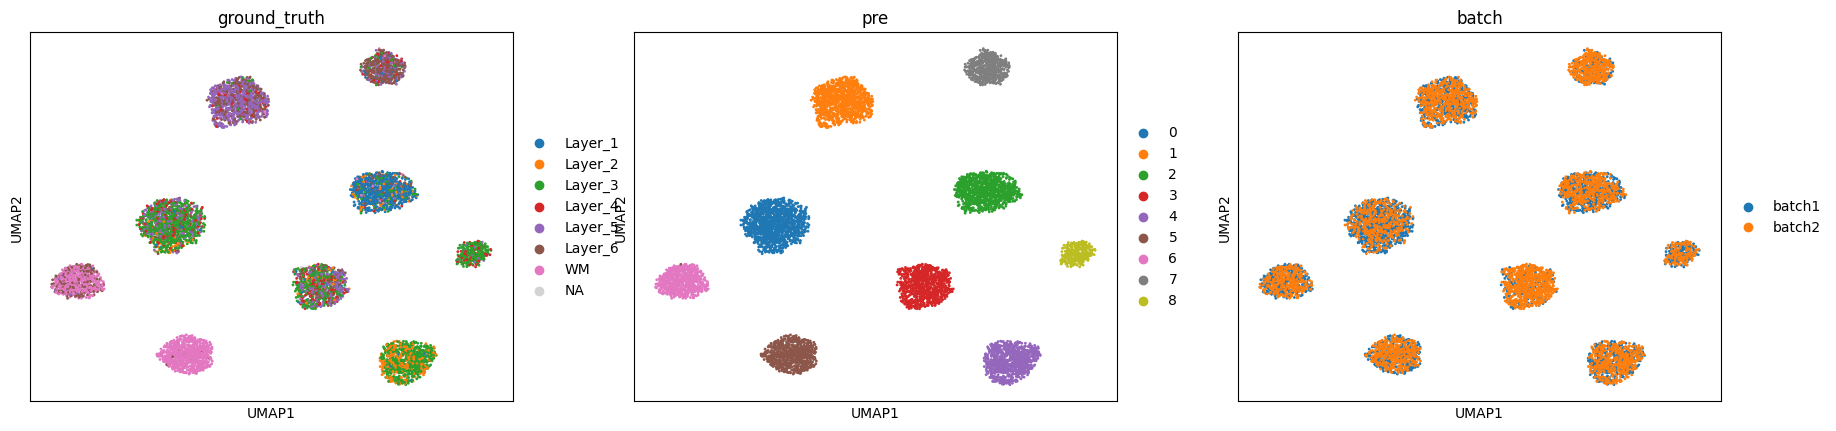

In [10]:
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'pre', 'batch'], show=True)

In [11]:
adata_151673 = adata[adata.obs['batch'] == 'batch1']
adata_151674 = adata[adata.obs['batch'] == 'batch2']

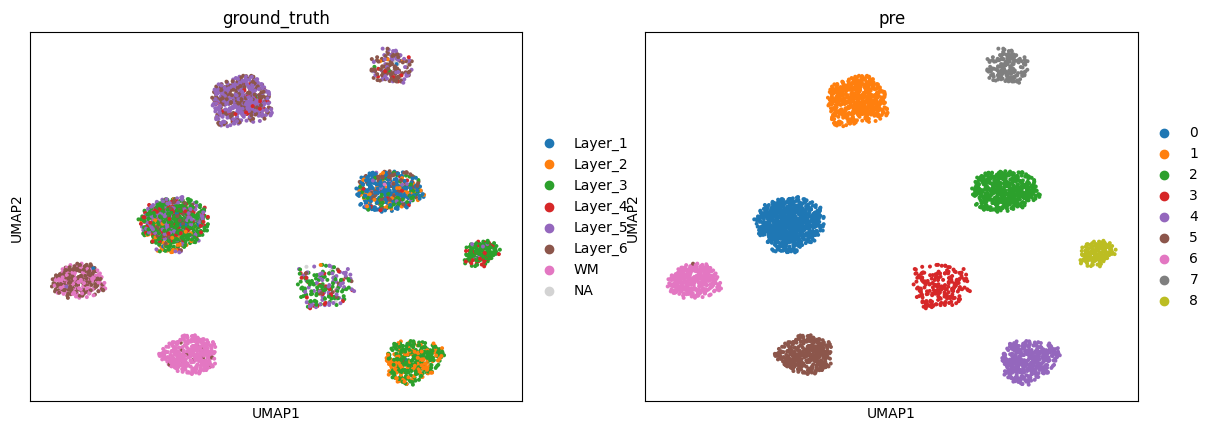

In [14]:
sc.pl.umap(adata_151673, color=['ground_truth', 'pre'])

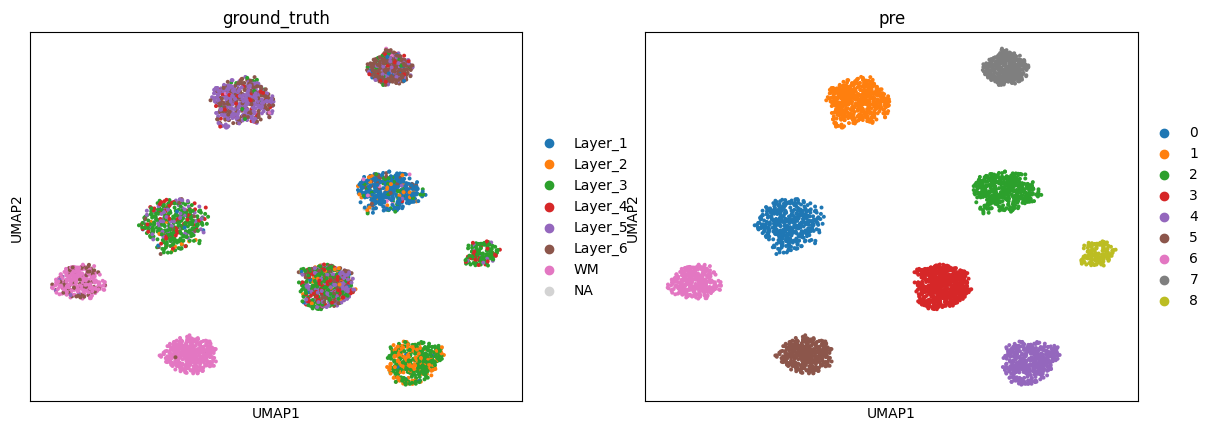

In [15]:
sc.pl.umap(adata_151674, color=['ground_truth', 'pre'])

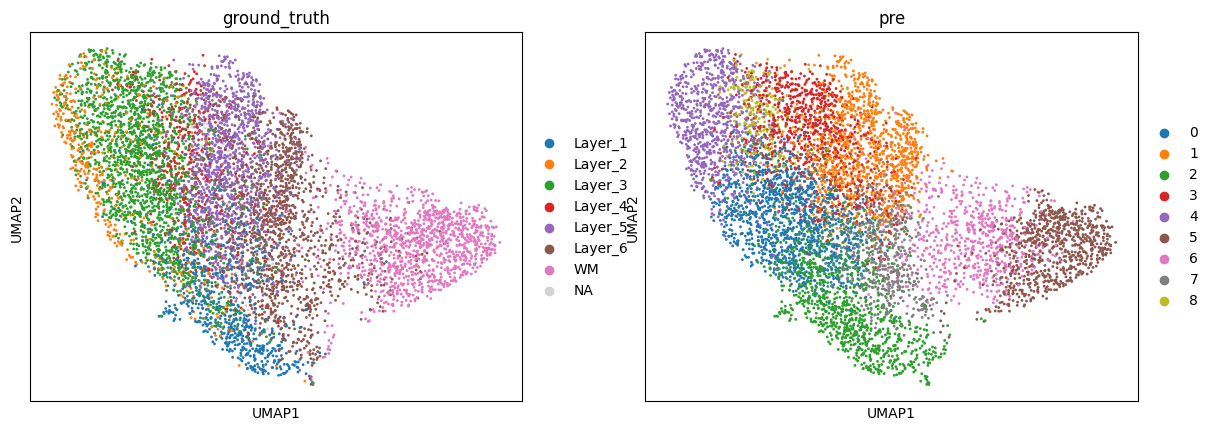

In [10]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# adata.var['mt'] = adata.var_names.str.startswith('MT-')
# sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mt'], jitter=0.4)

# 标准化和识别高度变异基因
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata_ESCA_train, min_mean=0.0125, max_mean=3, min_disp=0.5)
# adata = adata[:, adata.var['highly_variable']]
# sc.pl.highly_variable_genes(adata_ESCA_train)

# PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
# sc.pl.pca_variance_ratio(adata_ESCA_train, log=True, n_pcs=50)

# 邻接图
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# UMAP
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth','pre'])

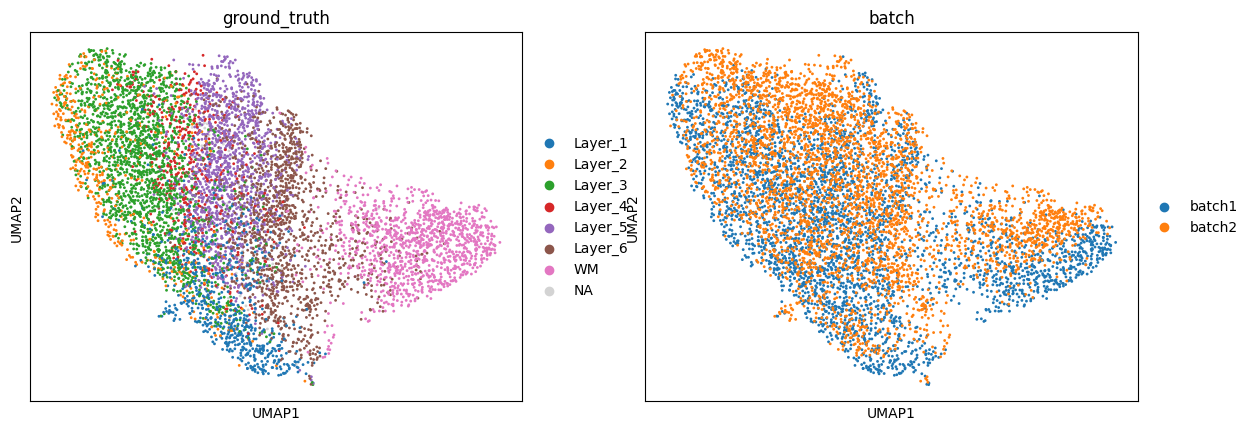

In [11]:
sc.pl.umap(adata, color=['ground_truth','batch'])